# Import libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sqlalchemy import create_engine

from underthesea import word_tokenize
import unicodedata
import re

import json

from collections import defaultdict

# Connect to workbench

In [48]:
username = 'root'
password = '08042004'
host = 'localhost'
port = '3306'
database = 'law_db'

# Tạo engine kết nối đến MySQL
engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}?charset=utf8mb4"
)


# Lấy dữ liệu 

In [49]:
# Lấy dữ liệu
df_case = pd.read_sql("SELECT id, content, text FROM `case`", con = engine)
df_law = pd.read_sql("SELECT id, article, title, content, type FROM law", con = engine)
df_case_law = pd.read_sql("SELECT case_id, point, clause, article, type, note FROM case_law", con = engine)

In [50]:
df_case.head()

,id,content,text
0,1,Vũ Tuấn T về tội “Cho vay lãi nặng trong giao ...,...
1,2,Tuyên bố bị cáo Trần Anh D phạm tội “Vi phạm ...,1 \n \nTÒA ÁN NHÂN DÂN \nCỘNG HÒA XÃ HỘI CHỦ N...
2,3,Cao Văn L,\n1 \nTÒA ÁN NHÂN DÂN QUẬN \nLONG BIÊN – TP H...
3,4,"Khoảng 12 giờ 30 phút ngày 26/01/2018, Phan Th...",TÒA ÁN NHÂN DÂN \nCỘNG HÒA XÃ HỘI CHỦ N...
4,5,Vi Van T phạm tội vi phạm quy định về quản lý...,2 \nTÒA ÁN NHÂN DÂN \nHUYỆN QUAN SƠN \nTỈNH TH...


In [51]:
df_law.head()

,id,article,title,content,type
0,1,Điều 1,Nhiệm vụ của Bộ luật hình sự,"""{\""info\"": \""Bộ luật hình sự có nhiệm vụ bảo ...",hình sự
1,2,Điều 2,Cơ sở của trách nhiệm hình sự,"""{\""info\"": \""\"", \""1\"": \""Chỉ người nào phạm ...",hình sự
2,3,Điều 3,Nguyên tắc xử lý,"""{\""info\"": \""\"", \""1\"": {\""a\"": \""Mọi hành vi...",hình sự
3,4,Điều 4,Trách nhiệm phòng ngừa và đấu tranh chống tội ...,"""{\""info\"": \""\"", \""1\"": \""Cơ quan Công an, Vi...",hình sự
4,5,Điều 5,Hiệu lực của Bộ luật hình sự đối với những hàn...,"""{\""info\"": \""\"", \""1\"": \""Bộ luật hình sự đượ...",hình sự


In [52]:
df_case_law.head()

,case_id,point,clause,article,type,note
0,1,None,None,30,None,thi hành án dân sự
1,1,None,None,9,None,thi hành án dân sự
2,1,None,None,7,None,thi hành án dân sự
3,1,None,None,6,None,thi hành án dân sự
4,1,None,None,2,None,thi hành án dân sự


# I. Chuẩn bị dữ liệu

## Hàm tiền xử lý dữ liệu

In [53]:
def preprocess_text(text):
    # text k la str => rỗng
    if not isinstance(text, str):
        return ""
    # chữ thường
    text = text.lower()

    # chuyển từ viết tắt 
    abbrList = {
        'blhs': 'bộ luật hình sự',
        'tths': 'tố tụng hình sự',
        'thhs': 'thi hành hình sự',
        'blds': 'bộ luật dân sự',
        'ttds': 'tố tụng dân sự',
        'thds': 'thi hành dân sự'
    }

    for abbr, full_form in abbrList.items():
        text = text.replace(abbr, full_form)
    

    text = unicodedata.normalize("NFC", text) # chuẩn hóa mã hóa Unicode > đồng nhất
    text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ0-9\s]", " ", text) #giữ chữ, số , loại kí tự đbiet
    
    # khoảng trắng thừa = 1 space 
    while '  ' in text:
        text = text.replace('  ', ' ')

    text = text.strip() # xoa space đầu cuối 


    return text


In [54]:
# test 
text = "Blhs và tths quy định thế nào? Thhs, blds, ttds, thds liên quan. blhs.                          abc"
result = preprocess_text(text)
print(result)

bộ luật hình sự và tố tụng hình sự quy định thế nào thi hành hình sự bộ luật dân sự tố tụng dân sự thi hành dân sự liên quan bộ luật hình sự abc


## Xử lý bản án từ text của bảng case

In [55]:
# chữ thường 
# chuyển từ viết tắt
# loại kí tự đặc biệt
# xóa khoảng trắng thừa

def preprocess_case(text):
    text = preprocess_text(text)
    delete_text = [
        "thành phố",
        "quận",
        "bà",
        "ông",
        "cộng hòa xã hội chủ nghĩa việt nam",
        "độc lập tự do hạnh phúc",
        "bản án số", 
        "tòa", "toà",
        "án nhân dân",
        "thành phần hội đồng xét xử",
        "gồm có",
        "nhân danh",
        "thẩm phán",
        "chủ toạ phiên", "chủ tọa phiên",
        "các hội thẩm nhân dân",
        "thư ký",
        "phiên",
        "viện kiểm sát nhân dân",
        "kiểm sát nhân dân",
        "kiểm sát viên",
        "hội đồng xét xử",
        "ngày", "tháng", "năm",
        "thụ lý số",
        "nghị quyết",
        "quyết định",
        "thông tư",
        "pháp lệnh",
    ]

    for item in delete_text:
        text = text.replace(item, "")
    
    # Bước 4: Xóa khoảng trắng thừa
    
    # khoảng trắng thừa = 1 space 
    while '  ' in text:
        text = text.replace('  ', ' ')

    text = text.strip() # xoa space đầu cuối 

    return text




## Xử lý dữ liệu bảng law

In [56]:
# "{
# \"info\": \"\", 
# \"1\": {
#     \"a\": \"Người phạm tội đã ngăn chặn hoặc làm giảm bớt tác hại của tội phạm;\", 
#     \"b\": \"Người phạm tội tự nguyện sửa chữa, bồi thường thiệt hại hoặc khắc phục hậu quả;\", 
#     \"c\": \"Phạm tội trong trường hợp vượt quá giới hạn phòng vệ chính đáng;\", 
#     \"d\": \"Phạm tội trong trường hợp vượt quá yêu cầu của tình thế cấp thiết;\", 
#     \"e\": \"Phạm tội trong trường hợp bị kích động về tinh thần do hành vi trái pháp luật của nạn nhân gây ra;\", 
#     }, 
# \"2\": \"Khi quyết định hình phạt, Tòa án có thể coi đầu thú hoặc tình tiết khác là tình tiết giảm nhẹ,.....\", 
# \"3\": \"Các tình tiết giảm nhẹ đã được Bộ luật này quy định là dấu hiệu định tội hoặc định khung thì ....\"
# }"


# truong hop chi co dieu 
# "{\"info\": \"Bộ luật hình sự có nhiệm vụ bảo vệ chủ quyền quốc gia, 
# an ninh của đất nước, bảo vệ chế độ xã hội chủ nghĩa, quyền con người, quyền công dân, 
# bảo vệ quyền bình đẳng giữa đồng bào các dân tộc, bảo vệ lợi ích của Nhà nước, tổ chức, 
# bảo vệ trật tự pháp luật, chống mọi hành vi phạm tội; giáo dục mọi người ý thức tuân theo pháp luật, 
# phòng ngừa và đấu tranh chống tội phạm. Bộ luật này quy định về tội phạm và hình phạt.\"}"

In [57]:
# tạo mảng lưu vết id 
law_article_list_ids = []
law_detail_list_ids = [] # detail = điểm, khoản, điều
#mảng lưu văn bản 
law_article_list = []
law_detail_list = []


count_lawID = 0
for index, row in df_law.iterrows():
    count_lawID +=1
    article = row['article']  
    title = row['title'] or ""
    law_type = row['type']
    law_id = row['id']
    content =""
    #chuyen json thanh dlieu python
    content_json = row["content"]
    print(">>> TYPE content_json:", type(content_json))
    try:
        if isinstance(content_json, str):
            content = json.loads(content_json)
            print(">>> TYPE content:", type(content))
            if isinstance(content, str):
                # load json 1
                content = json.loads(content)
                print(">>> TYPE content:", type(content))
        

    except Exception as e:
        print(e)
    
    # # điều > khoản key, value
    all_clause_value = ""
    for clause_key, clause_value in content.items():
        # print("clause_key",clause_key)
        # print("clause_value",clause_value)

        # nếu khoản là string > mỗi khoản 
        if isinstance(clause_value, str):
            if clause_key == "info":
                if not clause_value or clause_value.strip() == "":
                        continue  # bỏ qua nếu info rỗng
                else: # content cua luat 
                
                    clean_clause_value = preprocess_text(clause_value)
                    full_text = f"{clean_clause_value}"
               
                    # them vao mang document 
                    # law_documents.append(full_text) vi end for nay thi van add law_id thoi 
                    # law_doc_ids.append(f"{law_id}") vi end for nay thi van add law_id thoi 

                    all_clause_value += "- " +full_text + "\n"
            else:
                #khoan 1 dieu 2 bo luat hinh su 
                heading = f"khoản {clause_key} {article} {law_type}"

                # lam sach du lieu
                clean_heading = preprocess_text(heading)
                clean_clause_value = preprocess_text(clause_value)
                full_text = f"{clean_heading}: {clean_clause_value}"
         
                # them vao mang document 
                law_detail_list.append(full_text)
                law_detail_list_ids.append(f"{law_id}_{clause_key}")

                # print("law id", law_id)
                # print("clean_text",clean_text)

                all_clause_value += "- " + full_text + "\n"

        # khoản là dict >> có điểm 
        elif isinstance(clause_value, dict):
            all_point_value = ""
            for point_key, point_value in clause_value.items():
                # print("point_key",point_key)
                # print("point_value",point_value)

                heading = f"điểm {point_key} khoản {clause_key} {article} {law_type}"
                clean_heading = preprocess_text(heading)
                clean_point_value = preprocess_text(point_value)
                full_text = f"{clean_heading}: {clean_point_value}"

                law_detail_list.append(full_text)
                law_detail_list_ids.append(f"{law_id}_{clause_key}_{point_key}")

                # print("law id", law_id)
                # print("clean_text",clean_text)

                all_point_value +="-- " + full_text + "\n"
                
            
            # end for, end duyệt point của clause val htai => add all point 
            # print(all_point_value)
                # điểm a khoản 2 điều 3 hình sự: mọi hành vi ph
                # điểm b khoản 2 điều 3 hình sự: mọi pháp nhân thươ
                # điểm c khoản 2 điều 3 hình sự: nghiêm trị pháp nhân th
                # điểm d khoản 2 điều 3 hình sự: khoan hồng đối với pháp 
            # thêm vào law documents , thêm law_id: khoản 2 điều 3 
            
            
            heading = f"khoản {clause_key} {article} {law_type}"
            clean_heading = preprocess_text(heading)
            full_text_all_point = f"{clean_heading}:\n{all_point_value}"
            

            all_clause_value += "+ " +full_text_all_point + "\n"

            law_detail_list.append(all_clause_value)
            law_detail_list_ids.append(f"{law_id}_{clause_key}")
            

    # end for clause 
    # add law documents, thêm law_id : điều 3 
    # print(all_clause_value)
    heading = f"{article} {law_type}"
    clean_heading = preprocess_text(heading)
    full_text_all_clause = f"{clean_heading}:\n{all_clause_value}"

    law_article_list.append(full_text_all_clause)
    law_article_list_ids.append(f"{law_id}")

    law_detail_list.append(full_text_all_clause)
    law_detail_list_ids.append(f"{law_id}")

    # #test
    # if article == "Điều 1":print(full_text_all_clause)




>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE content: <class 'dict'>
>>> TYPE content_json: <class 'str'>
>>> TYPE content: <class 'str'>
>>> TYPE cont

In [58]:
# tạo 1 dict 
# key 51_1_s 
# value: law doc 

def create_law_dict(law_documents, law_doc_ids):
    law_dict = {}
    for i in range(len(law_documents)):
        text = law_documents[i]
        id = law_doc_ids[i]
        law_dict[id] = text
    return law_dict


law_article_dict = create_law_dict(law_article_list, law_article_list_ids)
law_detail_dict = create_law_dict(law_detail_list, law_detail_list_ids)
#test
for i, (doc_id, text) in enumerate(law_detail_dict.items()):
    if i >= 20:  # 5 docs 
        break
    print(f"ID: {doc_id}")
    print(f"Văn bản: {text[:200]}...\n")  # limit: 200 ki tu 

ID: 1
Văn bản: điều 1 hình sự:
- bộ luật hình sự có nhiệm vụ bảo vệ chủ quyền quốc gia an ninh của đất nước bảo vệ chế độ xã hội chủ nghĩa quyền con người quyền công dân bảo vệ quyền bình đẳng giữa đồng bào các dân ...

ID: 2_1
Văn bản: khoản 1 điều 2 hình sự: chỉ người nào phạm một tội đã được bộ luật hình sự quy định mới phải chịu trách nhiệm hình sự...

ID: 2_2
Văn bản: khoản 2 điều 2 hình sự: chỉ pháp nhân thương mại nào phạm một tội đã được quy định tại điều 76 của bộ luật này mới phải chịu trách nhiệm hình sự...

ID: 2
Văn bản: điều 2 hình sự:
- khoản 1 điều 2 hình sự: chỉ người nào phạm một tội đã được bộ luật hình sự quy định mới phải chịu trách nhiệm hình sự
- khoản 2 điều 2 hình sự: chỉ pháp nhân thương mại nào phạm một ...

ID: 3_1_a
Văn bản: điểm a khoản 1 điều 3 hình sự: mọi hành vi phạm tội do người thực hiện phải được phát hiện kịp thời xử lý nhanh chóng công minh theo đúng pháp luật...

ID: 3_1_b
Văn bản: điểm b khoản 1 điều 3 hình sự: mọi người phạm tội đều bình đẳng t

In [59]:
#test
print("số law_id", count_lawID)
print(f"len law_articles: {len(law_article_list)}")
print(f"len law_article_ids: {len(law_article_list_ids)} ")
print(f"len law_article_clause_point_list: {len(law_detail_list)}")
print(f"len law_article_clause_point_list_ids: {len(law_detail_list_ids)} ")

số law_id 1122
len law_articles: 1122
len law_article_ids: 1122 
len law_article_clause_point_list: 8641
len law_article_clause_point_list_ids: 8641 


In [60]:
#test chỉ điều 
print("test doc chỉ điều")
print(f"len law_articles: {len(law_article_list)}")
print(f"len law_article_ids: {len(law_article_list_ids)} ")
def print_test_law_list(list_id, list):
    r = []
    for id_, doc_ in zip(list_id, list):
        r.append({
            "id":id_,
            "doc": doc_

        })

    print(pd.DataFrame(r))

print_test_law_list(law_article_list_ids,law_article_list )

test doc chỉ điều
len law_articles: 1122
len law_article_ids: 1122 
        id                                                doc
0        1  điều 1 hình sự:\n- bộ luật hình sự có nhiệm vụ...
1        2  điều 2 hình sự:\n- khoản 1 điều 2 hình sự: chỉ...
2        3  điều 3 hình sự:\n+ khoản 1 điều 3 hình sự:\n--...
3        4  điều 4 hình sự:\n- khoản 1 điều 4 hình sự: cơ ...
4        5  điều 5 hình sự:\n- khoản 1 điều 5 hình sự: bộ ...
...    ...                                                ...
1117  1118  điều 203 thi hành án hình sự:\n- bộ cơ quan ng...
1118  1119  điều 204 thi hành án hình sự:\n- khoản 1 điều ...
1119  1120  điều 205 thi hành án hình sự:\n- khoản 1 điều ...
1120  1121  điều 206 thi hành án hình sự:\n- khoản 1 điều ...
1121  1122  điều 207 thi hành án hình sự:\n- khoản 1 điều ...

[1122 rows x 2 columns]


In [61]:
#test chỉ điều 
print("test doc dieu khoan dieu")
print(f"len law_article_clause_point_list: {len(law_detail_list)}")
print(f"len law_article_clause_point_list_ids: {len(law_detail_list_ids)} ")
print_test_law_list(law_detail_list_ids, law_detail_list)

test doc dieu khoan dieu
len law_article_clause_point_list: 8641
len law_article_clause_point_list_ids: 8641 
          id                                                doc
0          1  điều 1 hình sự:\n- bộ luật hình sự có nhiệm vụ...
1        2_1  khoản 1 điều 2 hình sự: chỉ người nào phạm một...
2        2_2  khoản 2 điều 2 hình sự: chỉ pháp nhân thương m...
3          2  điều 2 hình sự:\n- khoản 1 điều 2 hình sự: chỉ...
4      3_1_a  điểm a khoản 1 điều 3 hình sự: mọi hành vi phạ...
...      ...                                                ...
8636    1121  điều 206 thi hành án hình sự:\n- khoản 1 điều ...
8637  1122_1  khoản 1 điều 207 thi hành án hình sự: đối với ...
8638  1122_2  khoản 2 điều 207 thi hành án hình sự: đối với ...
8639  1122_3  khoản 3 điều 207 thi hành án hình sự: đối với ...
8640    1122  điều 207 thi hành án hình sự:\n- khoản 1 điều ...

[8641 rows x 2 columns]


## Tạo tập dữ liệu nhãn

## Tạo mảng ground_truth

{
id_bản_án_1: [id_điều_luật_1, id_điều_luật_2, ...], 
id_bản_án_2: [...],
 ...
}

{
case_id: [law_id_article_clause_point_1, law_id_article_clause_point_2, ...], 
case_id2: [...],
 ...
}

### Xử lý bảng case_law

In [62]:
# acticle + type case_law >> law_id trong law
# law_id_clause_point (article => law_id)

Truy vấn law_id của bảng law từ article, type của bảng case_law

In [63]:
# acticle + type case_law >> law_id trong law
# hàm get_law_id
def get_law_id_from_db(engine, param):
    query = "SELECT id FROM law WHERE article = %s AND type = %s"
    law_id = pd.read_sql(query,engine,params= param)  # Tuple
    if not law_id.empty:
        return law_id['id'].iloc[0]
    else:
        return None

In [64]:
# dict ground_truth
ground_truth_article_dict = defaultdict(list)
ground_truth_detail_dict = defaultdict(list)
#get law_id
for index, row in df_case_law.iterrows():
    case_id = row['case_id'] 
    article = row['article']  
    clause = row['clause'] 
    point = row['point'] 
    case_law_type = row['type'] 
    note = row['note'] 

    article_text = f"Điều {article}"
    
    # print(case_id, " ",article, " ",clause, " ", point, " ", note )

    #get law_id 
    # param tham so truyen vao phai la 1 tuple () or dict 
    param = (article_text, case_law_type)
    law_id = get_law_id_from_db(engine, param )

    # mỗi lần lặp thì reset key 
    article_key = clause_key = point_key = ""
    # law_id none là các điều nằm ngoài h.sự
    if law_id == None: 
        article_key = ""
    else: 
        article_key = f"{law_id}"
        if clause == None:
            clause_key = ""
        else: 
            clause_key = f"_{clause}"
            if point == None:
                point_key = ""
            else: point_key = f"_{point}"

    
    

    # law_id_clause_point (article => law_id)
    
    full_law_id = article_key + clause_key + point_key
    if full_law_id =="": continue # bỏ qua những luật ngoài hình sự
    # print(case_id, "_",target_id) 

    # 1 _ 51_1_i
    # 1 _ 51_1_s
    # 1 _ 51_2
    # 1 _ 52_1_g
    # 1 _ 35
    # 1 _ 47_1_a

    law_of_caseid_arr = ground_truth_article_dict[case_id]
    if article_key not in law_of_caseid_arr:
        ground_truth_article_dict[case_id].append(article_key)
    ground_truth_detail_dict[case_id].append(full_law_id)



#test

print("chỉ điều: ", ground_truth_article_dict)
print("len: ",len( ground_truth_article_dict))

print("all: ", ground_truth_detail_dict)
print("len: ",len( ground_truth_detail_dict))



chỉ điều:  defaultdict(<class 'list'>, {1: ['201', '532', '47', '35', '52', '51'], 2: ['759', '757', '562', '532', '47', '65', '1005', '51', '244'], 3: ['759', '757', '562', '1005', '532', '47', '51', '65', '244'], 4: ['1005', '65', '783', '781', '38', '51', '244'], 5: ['1005', '759', '757', '562', '244', '65', '35', '51'], 6: ['759', '757', '562', '754', '65', '1005', '244', '532', '51'], 7: ['562', '1005', '532', '51', '244', '190', '65'], 8: ['52', '1005', '35', '244', '759', '757', '562', '532', '47', '65', '51', '58'], 9: ['234', '1005', '562', '190', '65', '51', '244'], 10: ['1005', '532', '244', '65', '51'], 11: ['244', '54', '51'], 12: ['52', '562', '244', '532', '47', '51'], 13: ['532', '47', '562', '1005', '65', '51', '244'], 14: ['759', '757', '562', '532', '561', '47', '46', '1005', '65', '244', '51'], 15: ['532', '47', '65', '562', '244', '1005', '51'], 17: ['532', '54', '38', '562', '244', '51'], 18: ['562', '561', '65', '1005', '532', '244', '51'], 19: ['244', '562', '38

# II. Xây dựng mô hình 

TF-IDF là mô hình biến văn bản thành vector số

* TF: Tần suất của từ trong doc

* IDF: Độ hiếm của từ trong toàn bộ tập docs

* Kết quả: từ càng quan trọng trong doc và càng hiếm trong toàn tập --> trọng số càng cao

In [65]:
# xay mo hinh
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#min_df Loại bỏ từ xuất hiện ít hơn 2 văn bản >> tránh noise
#max_df Bỏ các từ xuất hiện phổ biến (trên 90% tài liệu) >> tránh các từ "là", "và", ...
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.9, sublinear_tf=True)
law_article_vectors = tfidf_vectorizer.fit_transform(law_article_list)  # điều 

law_detail_tfidf_vectorizer= TfidfVectorizer(min_df=2, max_df=0.9, sublinear_tf=True)
law_detail_vectors = law_detail_tfidf_vectorizer.fit_transform(law_detail_list) # điều khoản điểm

List Prediction

In [66]:
caseID_list =[]
for index, row in df_case.iterrows():
    case_id = row['id'] 
    caseID_list.append(case_id)

print(caseID_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 193, 194, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 229, 230, 231, 232, 23

In [ ]:
def create_predict_laws_by_tfidf(vectorizer, law_vectors, law_list_ids, k):
    #fit model 
    predictions = {}
    
    for index, row in df_case.iterrows():
        case_id = row['id'] 
        
        text = row['text']
        text = preprocess_case(text)
        
        # chuyen van ban thanh vector dạng so >>> query
        case_vector = vectorizer.transform([text])

        # tinh do tương đồng giữa case và all law document
        similarity_scores = cosine_similarity(case_vector, law_vectors).flatten()
  
        # sort (index của value) vs value từ thấp > cao 0 1 2 3 
        sorted_doc_index = similarity_scores.argsort()
        inverse_doc_index = sorted_doc_index[::-1] # đảo ngược

        # lay index của top k tài liệu có điểm tương đồng cao nhat 
        topK_index = inverse_doc_index[:k]

        # lay list id cua top k tuong dong nhat 
        
        topK_document_ids = []
        for i in topK_index:
            document_id = law_list_ids[i] # điều || điều khoản điểm
            topK_document_ids.append(document_id)
        predictions[case_id] = topK_document_ids
    return predictions # dict 

In [68]:
# #test
def print_test_predicted_dict(vectorizer, vector, list_id, k):
    pre = create_predict_laws_by_tfidf(vectorizer,vector, list_id, k)
    print(pre)

print_test_predicted_dict(tfidf_vectorizer, law_article_vectors, law_article_list_ids, 10)


{1: ['686', '548', '200', '988', '752', '499', '939', '794', '865', '982'], 2: ['794', '939', '686', '752', '499', '234', '244', '430', '982', '532'], 3: ['794', '686', '752', '939', '913', '548', '430', '688', '487', '1025'], 4: ['686', '794', '1018', '51', '65', '752', '988', '994', '244', '1025'], 5: ['686', '794', '752', '65', '939', '1025', '988', '499', '961', '244'], 6: ['939', '686', '794', '65', '988', '752', '952', '1025', '499', '982'], 7: ['794', '686', '752', '939', '1025', '65', '532', '536', '982', '988'], 8: ['794', '953', '686', '939', '975', '982', '988', '752', '536', '1111'], 9: ['794', '686', '65', '939', '952', '988', '953', '752', '234', '964'], 10: ['794', '244', '532', '232', '65', '234', '939', '548', '952', '1025'], 11: ['430', '244', '794', '988', '686', '499', '752', '953', '982', '964'], 12: ['794', '988', '244', '430', '686', '752', '953', '939', '976', '982'], 13: ['244', '794', '686', '939', '234', '752', '532', '1025', '232', '499'], 14: ['686', '939',

In [69]:
#test
print_test_predicted_dict(law_detail_tfidf_vectorizer, law_detail_vectors, law_detail_list_ids, 10)

{1: ['686_3', '686', '686_2', '201_1', '548', '201', '752', '752_6', '499', '200_5'], 2: ['794', '686_3', '686', '939', '752', '752_6', '499', '686_2', '499_2', '953'], 3: ['686_3', '686', '794', '752', '752_6', '686_2', '548', '752_3', '1025', '939'], 4: ['686_3', '686', '794', '686_2', '752', '752_6', '1018_3', '1018', '994', '65'], 5: ['686_3', '686', '794', '686_2', '752', '752_6', '65', '939', '499', '1025'], 6: ['686_3', '686', '939', '794', '686_2', '65', '752', '752_6', '988', '499'], 7: ['794', '752', '686_3', '752_6', '686', '1025', '939', '686_2', '499', '982'], 8: ['794', '953', '686_3', '686', '686_2', '752', '939', '953_4', '752_6', '982'], 9: ['794', '686_3', '686', '686_2', '65', '939', '752', '988', '952', '752_6'], 10: ['794', '532', '532_3', '65', '548', '939', '1025', '686_3', '686', '988'], 11: ['430_2', '430', '794', '686_3', '686', '988', '499', '752', '686_2', '752_6'], 12: ['794', '686_3', '686', '988', '752', '752_6', '686_2', '430', '430_2', '244_5'], 13: ['7

In [70]:
#test
from tabulate import tabulate
predict_dict_article = create_predict_laws_by_tfidf(tfidf_vectorizer, law_article_vectors, law_article_list_ids, 5)
predict_dict_detail = create_predict_laws_by_tfidf(law_detail_tfidf_vectorizer, law_detail_vectors, law_detail_list_ids, 5)

len_caseID_list = len(caseID_list)
print(len_caseID_list)

def create_short(n, str):
    return str[:n] + '...' if len(str) > n else str

def print_table_res(ground_truth, law_dict, predictions):
    for caseId in caseID_list:
        prediction_arr = predictions[caseId]
        ground_truth_caseId_arr = ground_truth[caseId]

        # print(prediction)
        # print(ground_truth_caseId)
        rows = []
        
        for predict, truth in zip(prediction_arr, ground_truth_caseId_arr):
            str_predict = law_dict[predict]
            str_truth = law_dict[truth]
            short_predict = create_short(30, str_predict)
            short_truth = create_short(30, str_truth)

            rows.append({
                "prediction": predict,
                "doc_predict": short_predict,
                "ground_truth_caseId": truth,
                "doc_truth": short_truth,
            })
        pd.set_option('display.max_rows', 10)
        dfff = (pd.DataFrame(rows))
        print(tabulate(dfff, headers='keys', tablefmt='grid'))
        break


print("KET QUA _ĐIỀU")
print_table_res(ground_truth_article_dict, law_article_dict, predict_dict_article)

10001
KET QUA _ĐIỀU
+----+--------------+------------------------------+-----------------------+---------------------------+
|    |   prediction | doc_predict                  |   ground_truth_caseId | doc_truth                 |
+====+==============+==============================+=======================+===========================+
|  0 |          686 | điều 260 tố tụng hình sự:    |                   201 | điều 201 hình sự:         |
|    |              | - kh...                      |                       | - khoản 1 đi...           |
+----+--------------+------------------------------+-----------------------+---------------------------+
|  1 |          548 | điều 122 tố tụng hình sự:    |                   532 | điều 106 tố tụng hình sự: |
|    |              | - kh...                      |                       | - kh...                   |
+----+--------------+------------------------------+-----------------------+---------------------------+
|  2 |          200 | điều 200 hình

In [71]:
#test
print("KET QUA _ĐIỂM KHOẢN ĐIỀU")
print_table_res(ground_truth_detail_dict, law_detail_dict, predict_dict_detail)

KET QUA _ĐIỂM KHOẢN ĐIỀU
+----+--------------+-----------------------------------+-----------------------+-----------------------------------+
|    |   prediction | doc_predict                       | ground_truth_caseId   | doc_truth                         |
+====+==============+===================================+=======================+===================================+
|  0 |        686_3 | - khoản 1 điều 260 tố tụng hìn... | 201_3                 | khoản 3 điều 201 hình sự: ngườ... |
+----+--------------+-----------------------------------+-----------------------+-----------------------------------+
|  1 |          686 | điều 260 tố tụng hình sự:         | 201_2                 | khoản 2 điều 201 hình sự: phạm... |
|    |              | - kh...                           |                       |                                   |
+----+--------------+-----------------------------------+-----------------------+-----------------------------------+
|  2 |        686_2 | - khoản 1

### 1. Precision tại k 
* tỷ lệ dự đoán đúng trong top k trả về
* bao nhiêu cái là đúng trong k điều luật mà mô hình trả về
* precision at k  = số luật đúng trong top k / k

In [72]:
#function
# predictedList ds du doan
# trueList: ground_truth
def precision_at_k(predictedList, trueList, k):
    if not predictedList:
        print("lỗi precision predictedList",predictedList)
    if not trueList:
        print("lỗi precision trueList", trueList)

    #list top k phần tử
    
    # giao của top k & ground_truth
    true_positives = set(predictedList) & set(trueList)
    return len(true_positives) / k

### 2. Recall tại k 
* % đúng của mô hình trong tất cả luật đúng
* recall at k  = số luật đúng trong top k / số luật đúng thực sự 

In [73]:
def recall_at_k(predictedList, trueList) :
    true_positives = set(predictedList) & set(trueList)

    if len(trueList) != 0 :
        return len(true_positives) / len(trueList)
    else : return 0.0



### 3. F1 score tại k 
* trung bình điều hòa (harmonic mean) của precision và recall
* f1-score = (2 * precision * recall) / (precision + recall)

In [74]:
def f1_at_k(precisionRes, recallRes) :
    if precisionRes + recallRes == 0:
        return 0.0
    return (2 * precisionRes * recallRes) / (precisionRes + recallRes)

### 4. MAP tại k (mean average precision)
* đánh giá độ chính xác theo thứ tự xuất hiện
* mức độ chính xác của list dự đoán sv list đúng trong top k kết quả



In [75]:
def average_precision(predictedList, trueList):
    sum_precision_at_index = 0.0
    count_true_doc_topK = 0
    for i in range(len(predictedList)):
        doc_id =predictedList[i]
        if doc_id in trueList: # nếu doc đúng (thuộc ground_truth)
            count_true_doc_topK += 1
            # vì i từ 0
            index = i + 1
            precision_at_index = count_true_doc_topK / index
            sum_precision_at_index += precision_at_index
    
    if len(trueList) == 0: 
        return 0.0
    else: return sum_precision_at_index / len(trueList)


### Đánh giá tổng thể
tính trung bình các chỉ số trên all tập dữ liệu predict, true 

In [76]:
# Hàm tính trung bình các chỉ số cho toàn bộ dữ liệu
def evaluate_all(predictions_dict, ground_truth_dict, k ):
    precisions, recalls, f1_scores, maps = [], [], [], []

    # gtruth - tap chuan 
    # caseid in predict ma k trong gtruth - tap rac > k phai nhãn thật 
    for case_id in ground_truth_dict:
        if case_id in predictions_dict:
            predicted_arr = predictions_dict[case_id]
        else: predicted_arr = []

        truth_arr = ground_truth_dict[case_id]
        
        precision = precision_at_k(predicted_arr, truth_arr, k)
        recall = recall_at_k(predicted_arr, truth_arr)
        f1_score = f1_at_k(precision, recall)
        ap = average_precision(predicted_arr, truth_arr)

        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1_score)
        maps.append(ap)


    return precisions, recalls, f1_scores, maps


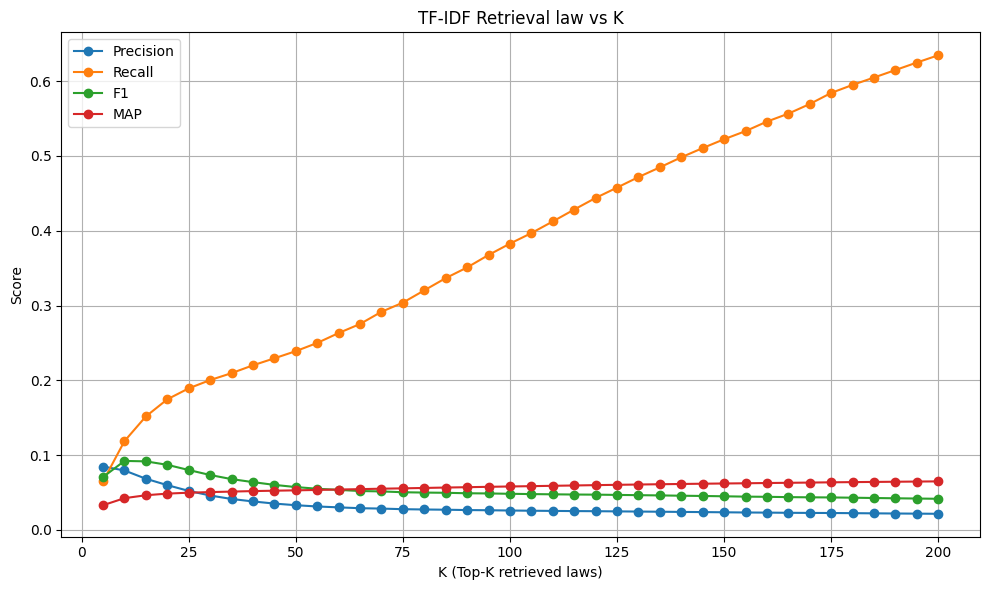

In [77]:
# #mảng k = [5, 10, 15, 20, ... , 200]
# # k_arr = list(range(5, 21, 5))
k_arr = list(range(5, 201, 5))

# #mỗi k, tính giá trị trung bình
results = {'K': [], 'Precision': [], 'Recall': [], 'F1': [], 'MAP': []}

for k in k_arr:
    prediction_article_dict = create_predict_laws_by_tfidf(tfidf_vectorizer, law_article_vectors, law_article_list_ids, k)
    
    precision_list, recall_list, f1_list, map_list = [], [], [], [] # ĐIỀU
    precision_detail_list, recall_detail_list, f1_detail_list, map_detail_list = [], [], [], [] # ĐIỂM KHOẢN ĐIỀU

    #đánh giá tổng thể
    precision_list, recall_list, f1_list, map_list = evaluate_all(prediction_article_dict  ,ground_truth_article_dict, k)
    
    avg_precision= np.mean(precision_list)
    avg_recall= np.mean(recall_list)
    avg_f1= np.mean(f1_list)
    avg_map= np.mean(map_list)

    
    results['K'].append(k)
    results['Precision'].append(avg_precision)
    results['Recall'].append(avg_recall)
    results['F1'].append(avg_f1)
    results['MAP'].append(avg_map)


# results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
plt.plot(results['K'], results['Precision'], marker='o', label='Precision')
plt.plot(results['K'], results['Recall'], marker='o', label='Recall')
plt.plot(results['K'], results['F1'], marker='o', label='F1')
plt.plot(results['K'], results['MAP'], marker='o', label='MAP')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF Retrieval law vs K")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
    
    

    

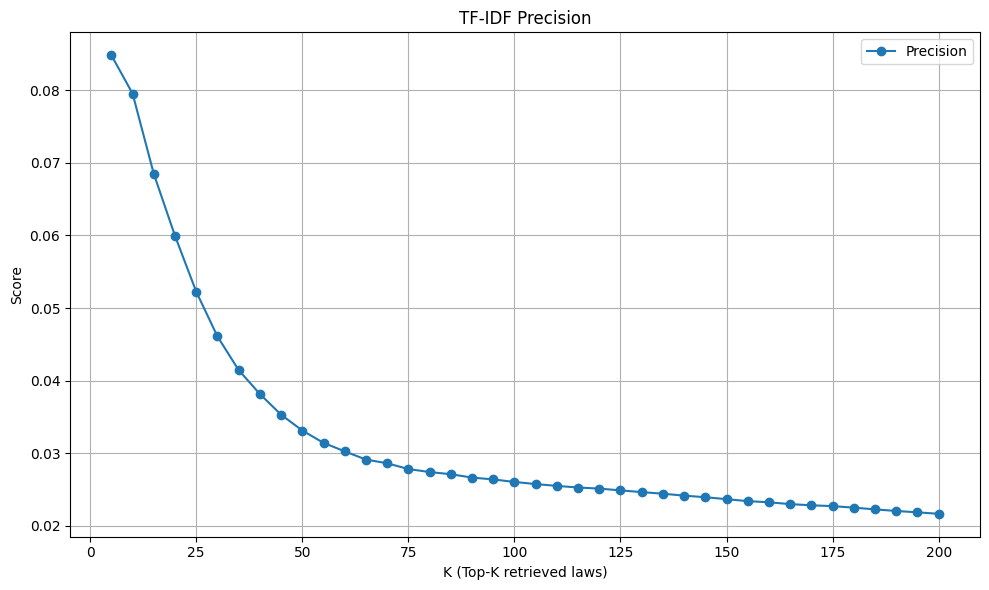

In [95]:
plt.figure(figsize=(10, 6))
plt.plot(results['K'], results['Precision'], marker='o', label='Precision')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

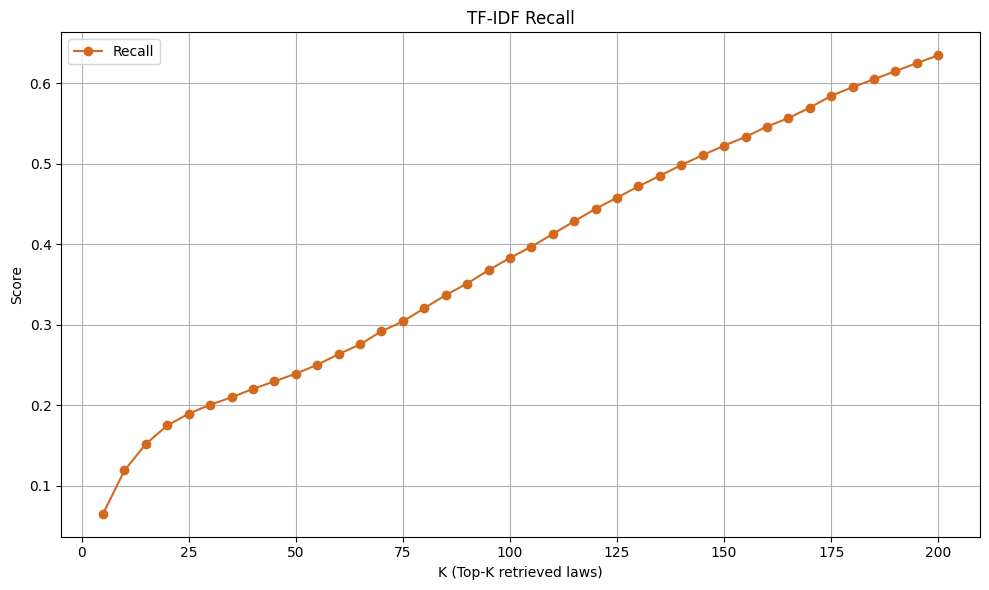

In [84]:
plt.figure(figsize=(10, 6))
plt.plot(results['K'], results['Recall'], marker='o', label='Recall', color = 'chocolate')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

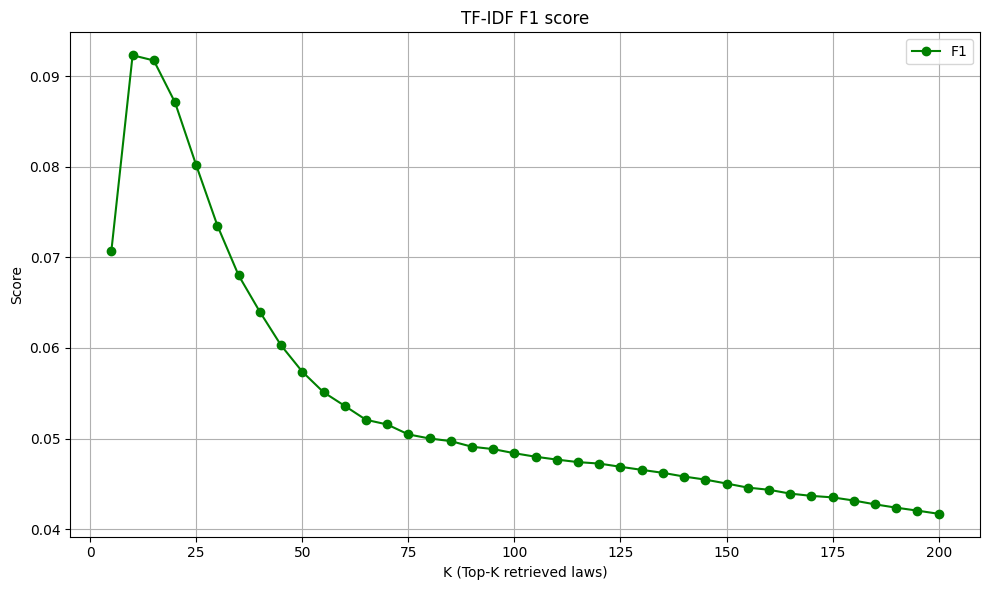

In [85]:
plt.figure(figsize=(10, 6))
plt.plot(results['K'], results['F1'], marker='o', label='F1' , color = 'green')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF F1 score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

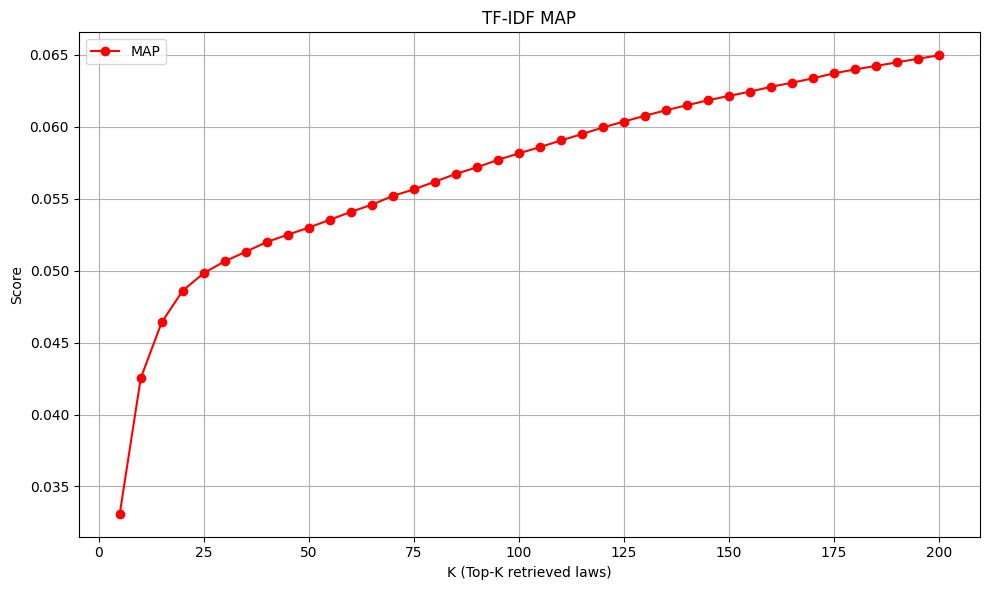

In [89]:
plt.figure(figsize=(10, 6))
plt.plot(results['K'], results['MAP'], marker='o', label='MAP' , color = 'red')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF MAP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Xuất CSV

In [ ]:
import csv
# Hàm xuất CSV
def save_metric_to_csv(filename, k_arr, scores, title):
    with open(filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([title])  # tên title 
        writer.writerow(["topk", "score"])
        for k, score in zip(k_arr, scores):
            writer.writerow([k, score])

In [83]:
# Xuất từng file
save_metric_to_csv("precision.csv", k_arr, results['Precision'], "Precision")
save_metric_to_csv("recall.csv", k_arr,results['Recall'] , "Recall")
save_metric_to_csv("f1.csv", k_arr, results['F1'], "F1")
save_metric_to_csv("map.csv", k_arr, results['MAP'], "MAP")


# THỐNG KÊ & BIỂU ĐỒ CỦA LUẬT ĐIỀU KHOẢN

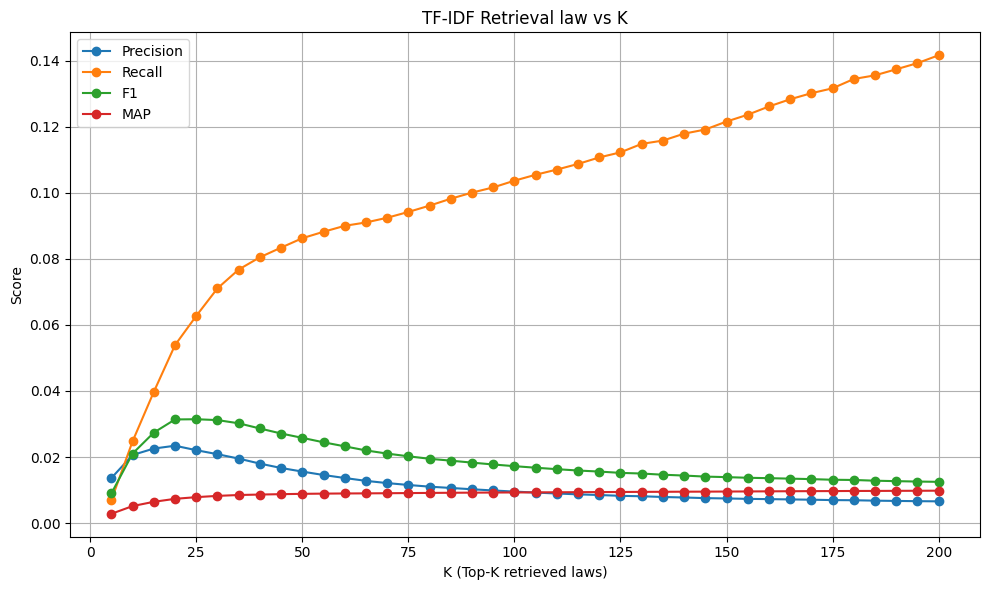

In [90]:
# #mỗi k, tính giá trị trung bình
resultsDetail = {'K': [], 'Precision': [], 'Recall': [], 'F1': [], 'MAP': []}

for k in k_arr:
    prediction_detail_dict = create_predict_laws_by_tfidf(law_detail_tfidf_vectorizer, law_detail_vectors, law_detail_list_ids, k)

    precision_detail_list, recall_detail_list, f1_detail_list, map_detail_list = [], [], [], [] # ĐIỂM KHOẢN ĐIỀU

    #đánh giá tổng thể DETAIL
    precision_detail_list, recall_detail_list, f1_detail_list, map_detail_list = evaluate_all(prediction_detail_dict  ,ground_truth_detail_dict, k)
    
    avg_precision_detail= np.mean(precision_detail_list)
    avg_recall_detail= np.mean(recall_detail_list)
    avg_f1_detail= np.mean(f1_detail_list)
    avg_map_detail= np.mean(map_detail_list)

    
    resultsDetail['K'].append(k)
    resultsDetail['Precision'].append(avg_precision_detail)
    resultsDetail['Recall'].append(avg_recall_detail)
    resultsDetail['F1'].append(avg_f1_detail)
    resultsDetail['MAP'].append(avg_map_detail)


# results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
plt.plot(resultsDetail['K'], resultsDetail['Precision'], marker='o', label='Precision')
plt.plot(resultsDetail['K'], resultsDetail['Recall'], marker='o', label='Recall')
plt.plot(resultsDetail['K'], resultsDetail['F1'], marker='o', label='F1')
plt.plot(resultsDetail['K'], resultsDetail['MAP'], marker='o', label='MAP')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF Retrieval law vs K")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Xuất từng file
save_metric_to_csv("precision_detail.csv", k_arr, resultsDetail['Precision'], "Precision")
save_metric_to_csv("recall_detail.csv", k_arr,resultsDetail['Recall'] , "Recall")
save_metric_to_csv("f1_detail.csv", k_arr, resultsDetail['F1'], "F1")
save_metric_to_csv("map_detail.csv", k_arr, resultsDetail['MAP'], "MAP")


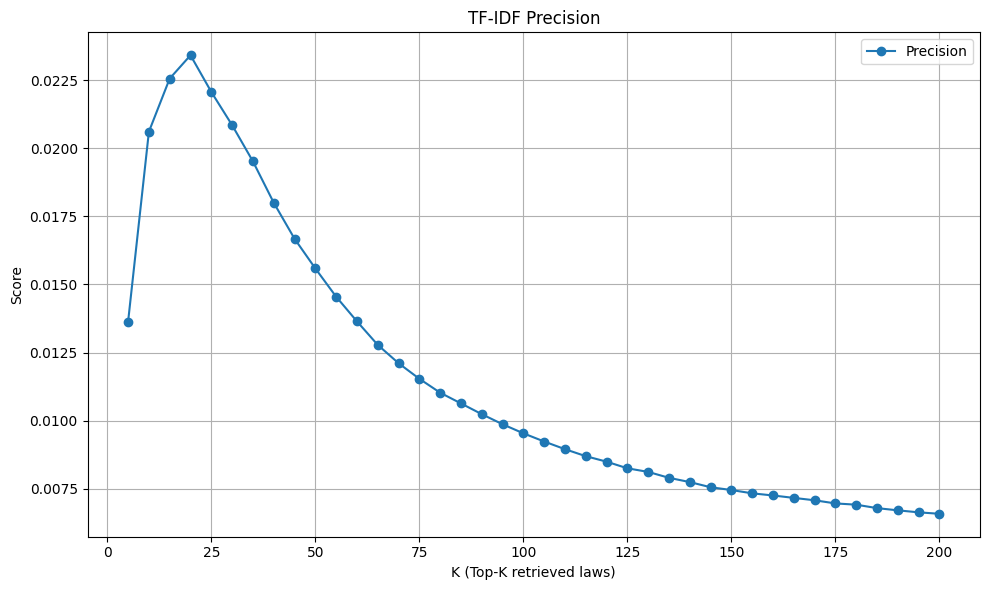

In [91]:
plt.figure(figsize=(10, 6))
plt.plot(resultsDetail['K'], resultsDetail['Precision'], marker='o', label='Precision')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

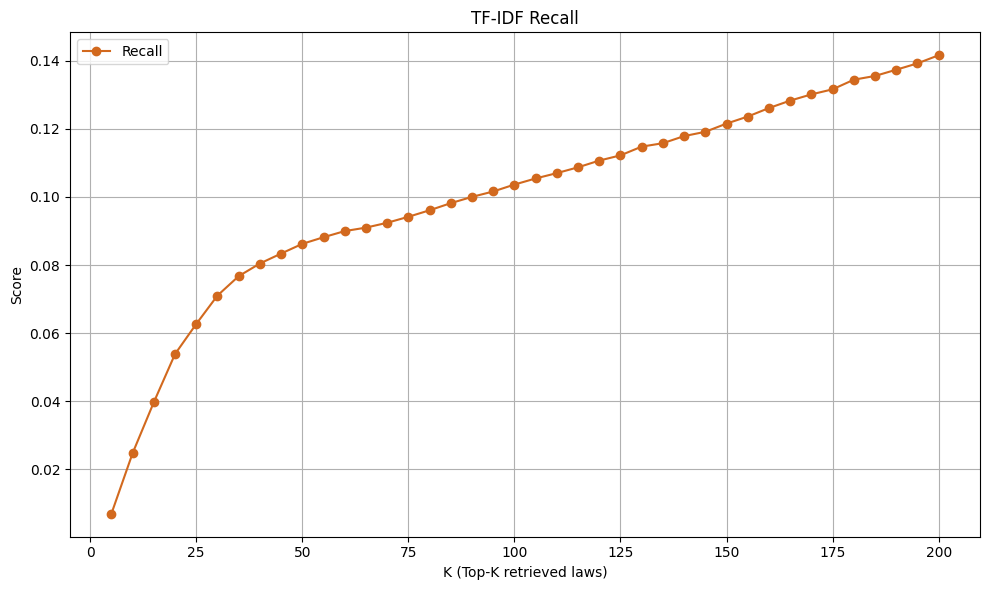

In [92]:
plt.figure(figsize=(10, 6))
plt.plot(resultsDetail['K'], resultsDetail['Recall'], marker='o', label='Recall', color = 'chocolate')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

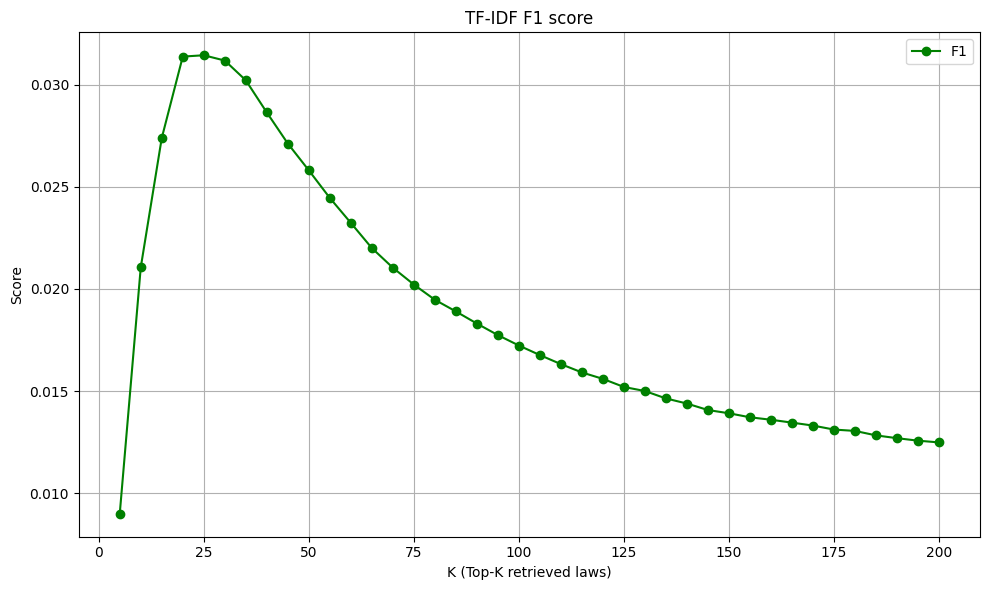

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(resultsDetail['K'], resultsDetail['F1'], marker='o', label='F1' , color = 'green')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF F1 score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

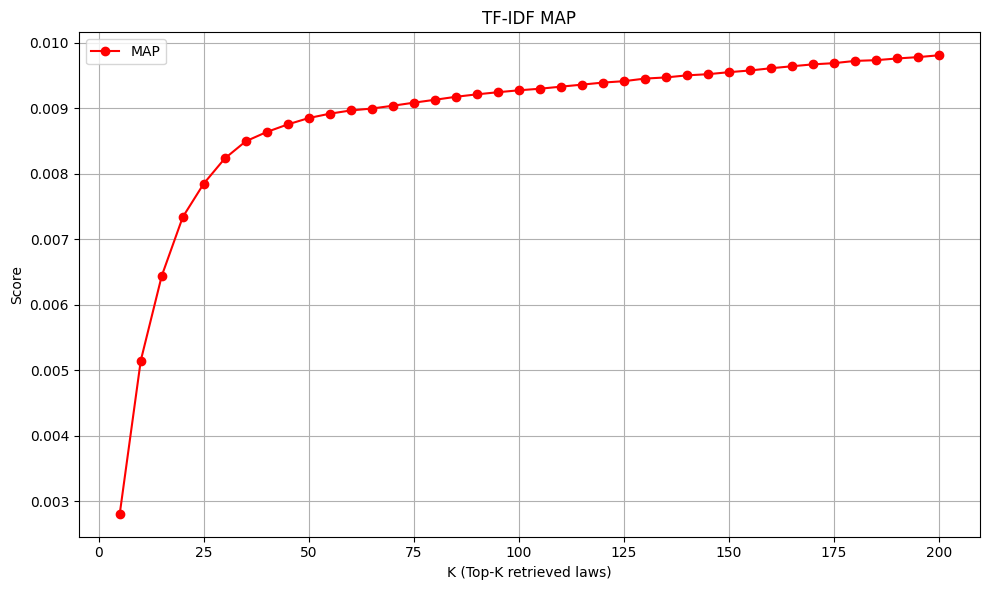

In [94]:
plt.figure(figsize=(10, 6))
plt.plot(resultsDetail['K'], resultsDetail['MAP'], marker='o', label='MAP' , color = 'red')
plt.xlabel("K (Top-K retrieved laws)")
plt.ylabel("Score")
plt.title("TF-IDF MAP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()